# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Zaki Nanda Wahyudi | 5054251007 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [75]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from IPython.display import display
from scipy.stats import skew

pd.set_option("display.show_dimension", False)

In [76]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")

print("\n============ Dataset Shape ============")
print(f"Baris: {df.shape[0]}")
print(f"Kolom: {df.shape[1]}")

print("\n=========== Data Type ==============")
print(df.dtypes)

print("\n============ Statistik Deskriptif =============")
display(df.describe())

print("\n============ Missing Value ===============")
miss = df.isnull().sum()
miss_perc = (df.isnull().sum() / len(df)) * 100
miss_df = pd.DataFrame(
    {"Missing Value": miss, "Persentase": miss_perc}
)
miss_df


============ Dataset Shape ============
Baris: 6819
Kolom: 96

=========== Data Type ==============
Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
                                                             ...   
 Liability to Equity                                        float64
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
dtype: object

============ Statistik Deskriptif =============


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000



============ Missing Value ===============


,Missing Value,Persentase
Bankrupt?,0,0.0
ROA(C) before interest and depreciation before interest,0,0.0
ROA(A) before interest and % after tax,0,0.0
ROA(B) before interest and depreciation after tax,0,0.0
Operating Gross Margin,0,0.0
...,...,...
Liability to Equity,0,0.0
Degree of Financial Leverage (DFL),0,0.0
Interest Coverage Ratio (Interest expense to EBIT),0,0.0
Net Income Flag,0,0.0


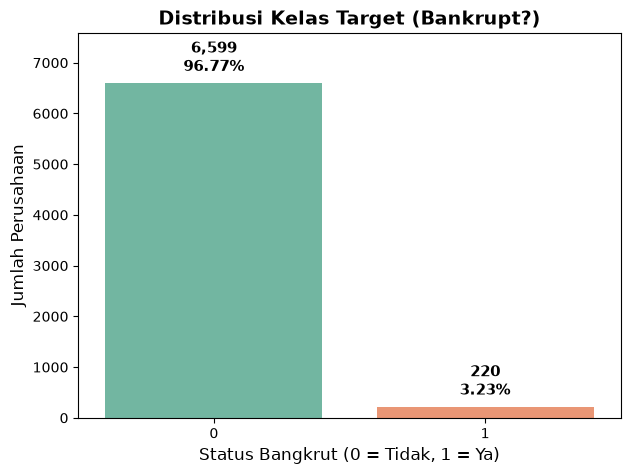

In [77]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize = (7, 5))
ax = sns.countplot(data = df, x = "Bankrupt?", hue = "Bankrupt?", palette = "Set2", legend=False)
total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = height/total *100
    ax.annotate(f"{int(height):,}\n{percentage:.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha = "center", va = "bottom", fontsize = 11, fontweight = "bold", xytext = (0, 5), textcoords="offset points")

plt.title("Distribusi Kelas Target (Bankrupt?)", fontsize = 14, fontweight = "bold")
plt.xlabel("Status Bangkrut (0 = Tidak, 1 = Ya)", fontsize = 12)
plt.ylabel("Jumlah Perusahaan", fontsize = 12)
plt.ylim(0, max(df["Bankrupt?"].value_counts()) * 1.15)

plt.show()

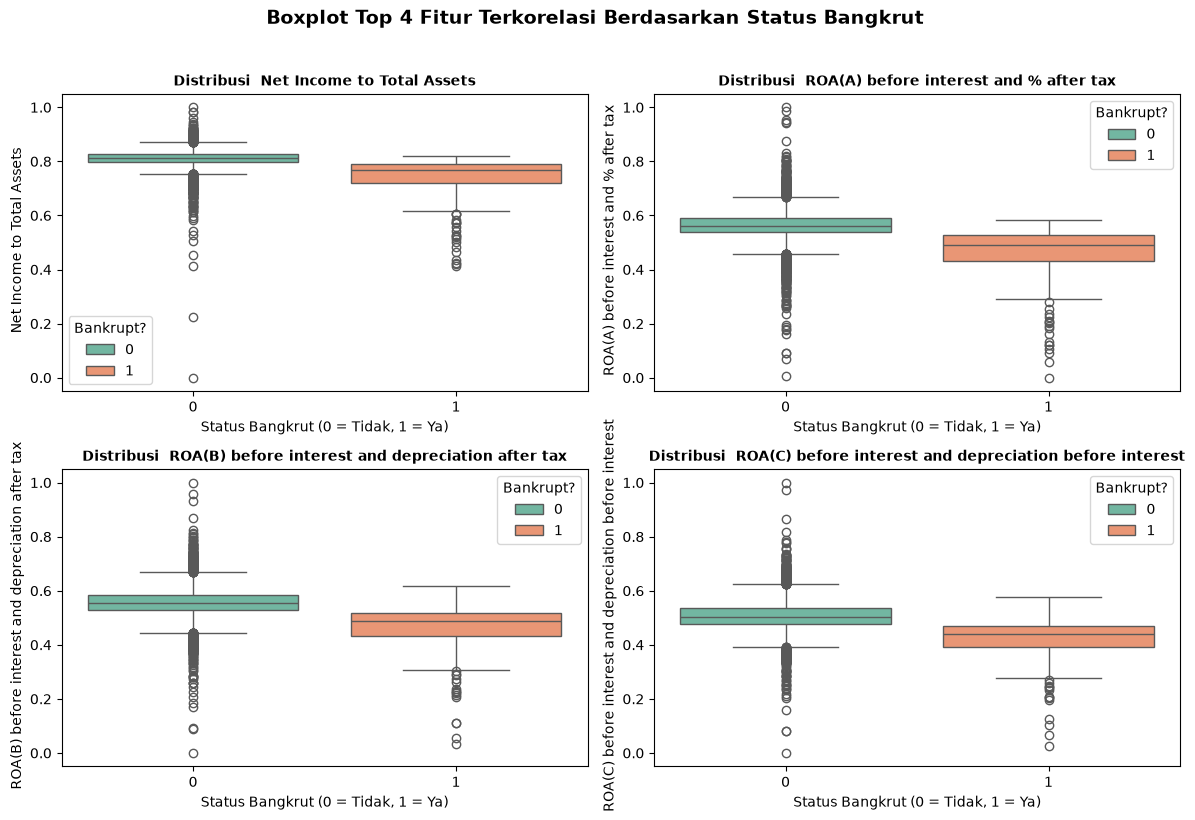

In [78]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
top_corr_features = (
    df.corr()["Bankrupt?"].abs().sort_values(ascending=False).index[1:5].tolist()
)

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(top_corr_features):
    sns.boxplot(data = df, x ="Bankrupt?", y = col, hue = "Bankrupt?", ax = axes[i], palette = "Set2")
    axes[i].set_title(f"Distribusi {col}", fontsize = 10, fontweight = "bold")
    axes[i].set_xlabel("Status Bangkrut (0 = Tidak, 1 = Ya)")
    axes[i].set_ylabel(col)

plt.suptitle("Boxplot Top 4 Fitur Terkorelasi Berdasarkan Status Bangkrut", fontsize = 14, fontweight = "bold", y=1.02)
plt.tight_layout()
plt.show()

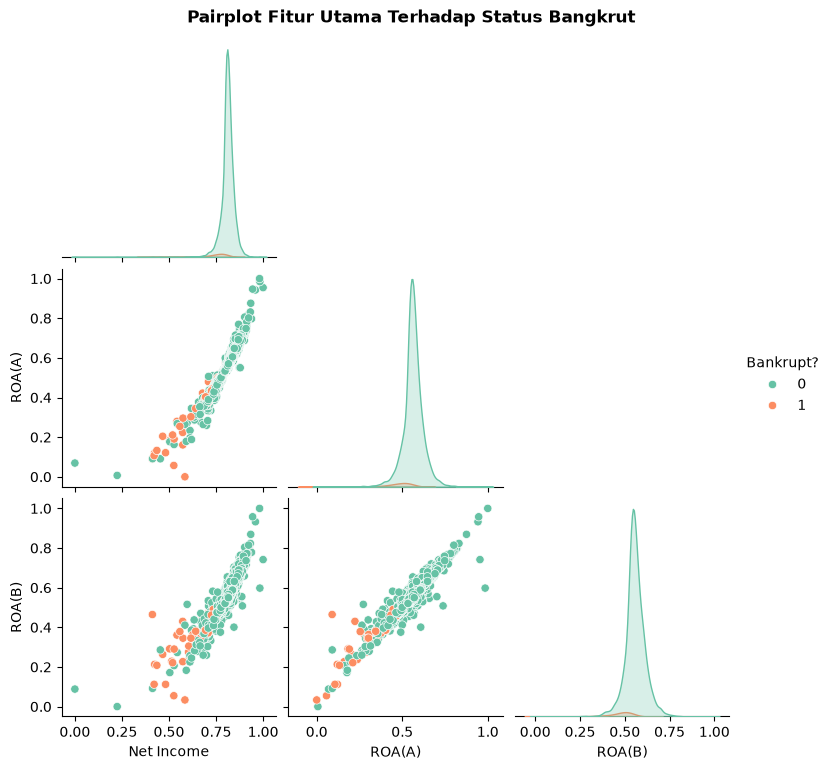

In [79]:
selected_cols = df[top_corr_features[0:3] + ["Bankrupt?"]].copy()
selected_cols.columns = ['Net Income', 'ROA(A)', 'ROA(B)', 'Bankrupt?']
g = sns.pairplot(selected_cols, hue = "Bankrupt?", palette = "Set2", corner = True, diag_kind = "kde")
g.fig.suptitle('Pairplot Fitur Utama Terhadap Status Bangkrut', y=1.02, fontsize=12, fontweight='bold')
plt.show()

In [80]:
print(f"Jumlah Data Duplikat: {df.duplicated().sum()}")
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Kolom wajib dihapus: {constant_cols}")

Jumlah Data Duplikat: 0
Kolom wajib dihapus: [' Net Income Flag']


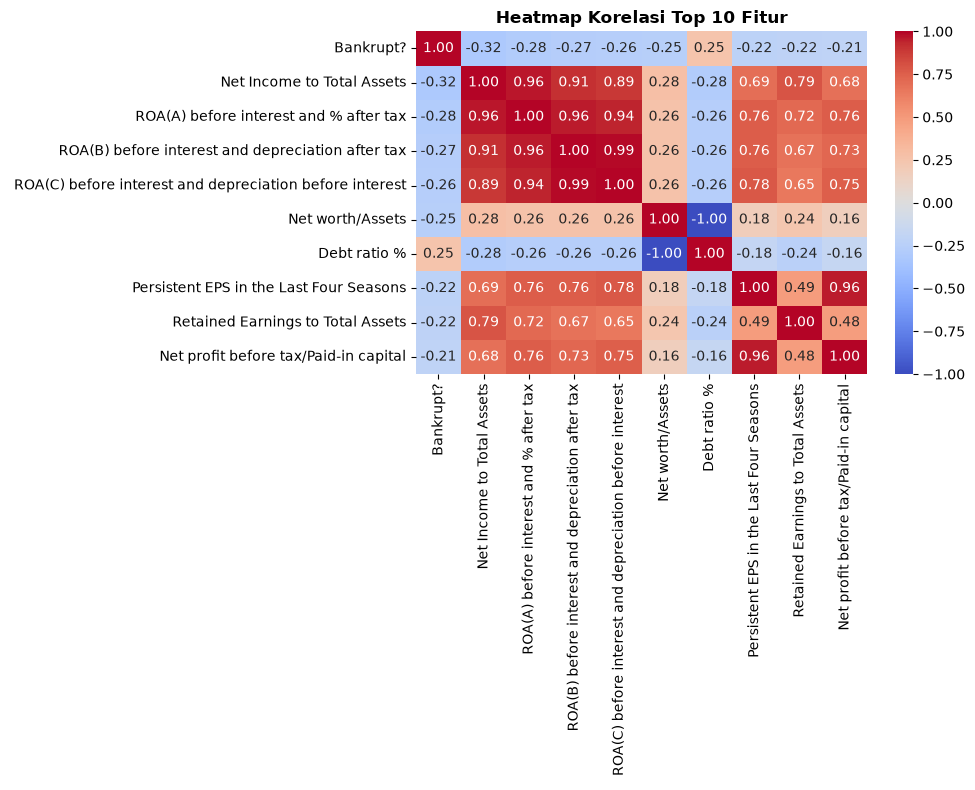

In [81]:
top_10_cols = (
    df.corr()["Bankrupt?"].abs().sort_values(ascending=False).index[0:10].tolist()
)

plt.figure(figsize = (10, 8))
sns.heatmap(df[top_10_cols].corr(), annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Heatmap Korelasi Top 10 Fitur", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [82]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
total_missing = df.isnull().sum().sum()
print(f"Total Missing Value: {total_missing}")
print("Karena tidak ada missing value, maka tidak perlu dilakukan imputasi data")

Total Missing Value: 0
Karena tidak ada missing value, maka tidak perlu dilakukan imputasi data


In [83]:
# Buang kolom dengan 1 nilai unik
df_clean = df.drop(columns = constant_cols)
print(f"Ukuran data awal: {df.shape}")
print(f"Ukuran data bersih: {df_clean.shape}")

Ukuran data awal: (6819, 96)
Ukuran data bersih: (6819, 95)


In [84]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Jumlah Fitur Kategorikal: {len(categorical_cols)}")

Jumlah Fitur Kategorikal: 0


In [85]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_clean.drop(columns = "Bankrupt?")
y = df_clean["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print("Proporsi kelas pada train set:")
print(y_train.value_counts(normalize = True) * 100)
print("Proporsi kelas pada test set:")
print(y_test.value_counts(normalize = True) * 100)


Ukuran X_train: (5455, 94)
Ukuran X_test: (1364, 94)
Proporsi kelas pada train set:
Bankrupt?
0    96.773602
1     3.226398
Name: proportion, dtype: float64
Proporsi kelas pada test set:
Bankrupt?
0    96.774194
1     3.225806
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [86]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
model_gn = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gn.fit(X_train, y_train)

print("Model Berhasil Dilatih!")

Model Berhasil Dilatih!


In [87]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gn = model_gn.predict(X_test)
y_proba_gn = model_gn.predict_proba(X_test)[:, 1]

print("Prediksi berhasil dilakukan pada test set!")


Prediksi berhasil dilakukan pada test set!


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [88]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
model_en = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_en.fit(X_train, y_train)
print("Model Berhasil Dilatih!")

Model Berhasil Dilatih!


In [89]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_en = model_en.predict(X_test)
y_proba_en = model_en.predict_proba(X_test)[:, 1]
print("Prediksi berhasil dilakukan pada test set!")


Prediksi berhasil dilakukan pada test set!


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [99]:
def get_metrics(y_test, y_pred, y_proba):
    report = classification_report(y_test, y_pred, output_dict=True)
    return {
        'Precision (Bangkrut)': report['1']['precision'],
        'Recall (Bangkrut)': report['1']['recall'],
        'F1-Score (Bangkrut)': report['1']['f1-score'],
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Accuracy Overall': report['accuracy']
    }

# Hitung metrik riil dari kedua model
comparison_df = pd.DataFrame({
    'Gini (model_gn)': get_metrics(y_test, y_pred_gn, y_proba_gn),
    'Entropy (model_en)': get_metrics(y_test, y_pred_en, y_proba_en)
})

print(comparison_df)

                      Gini (model_gn)  Entropy (model_en)
Precision (Bangkrut)         0.395349            0.357143
Recall (Bangkrut)            0.386364            0.340909
F1-Score (Bangkrut)          0.390805            0.348837
ROC-AUC                      0.683333            0.660227
Accuracy Overall             0.961144            0.958944


In [102]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

best_criterion = 'gini' 
max_depth_list = [1, 2, 3, 5, 10, None]

depth_results = []

for depth in max_depth_list:
    model = DecisionTreeClassifier(
        criterion=best_criterion, 
        max_depth=depth, 
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    depth_results.append({
        'max_depth': str(depth),
        'train_acc': accuracy_score(y_train, y_pred_train),
        'test_acc': accuracy_score(y_test, y_pred_test),
        'train_recall': recall_score(y_train, y_pred_train),
        'test_recall': recall_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train),
        'test_f1': f1_score(y_test, y_pred_test)
    })

df_depth_eval = pd.DataFrame(depth_results)
df_depth_eval

,max_depth,train_acc,test_acc,train_recall,test_recall,train_f1,test_f1
0,1,0.967736,0.967742,0.000000,0.000000,0.000000,0.000000
1,2,0.969936,0.969941,0.073864,0.090909,0.136842,0.163265
2,3,0.972319,0.971408,0.238636,0.204545,0.357447,0.315789
3,5,0.977452,0.969208,0.562500,0.409091,0.616822,0.461538
4,10,0.994684,0.961144,0.886364,0.363636,0.914956,0.376471
5,None,1.000000,0.961144,1.000000,0.386364,1.000000,0.390805


In [103]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

accuracy_data = {
    'max_depth': df_depth_eval['max_depth'].tolist(),
    'train_acc': df_depth_eval['train_acc'].tolist(),
    'test_acc': df_depth_eval['test_acc'].tolist()
}

print("Akurasi berhasil dihitung dan disimpan!")

Akurasi berhasil dihitung dan disimpan!


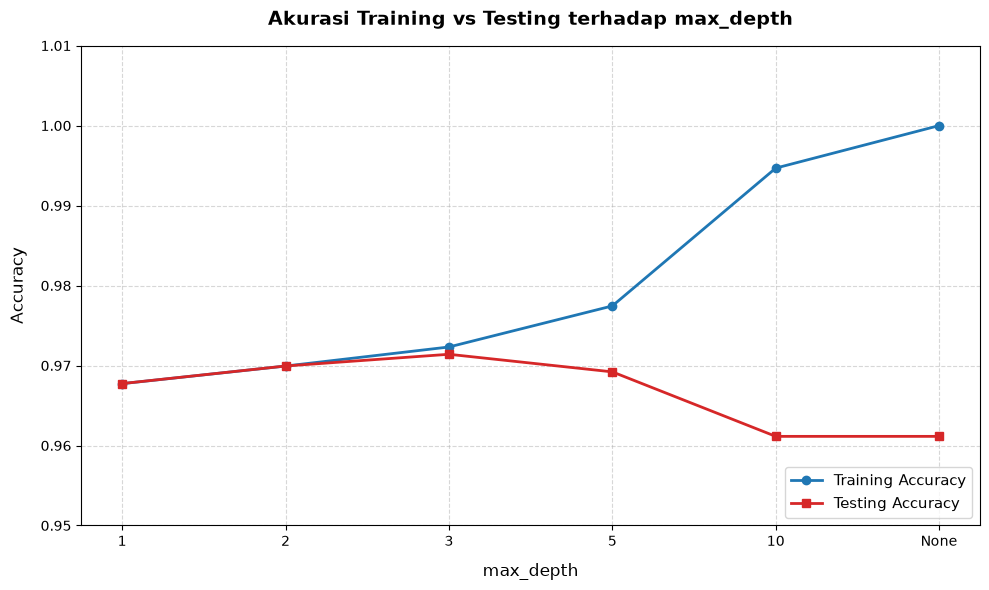

In [104]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(10, 6))

plt.plot(
    accuracy_data['max_depth'], 
    accuracy_data['train_acc'], 
    marker='o', 
    linewidth=2, 
    label='Training Accuracy', 
    color='#1f77b4'
)

plt.plot(
    accuracy_data['max_depth'], 
    accuracy_data['test_acc'], 
    marker='s', 
    linewidth=2, 
    label='Testing Accuracy', 
    color='#d62728'
)

plt.title('Akurasi Training vs Testing terhadap max_depth', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('max_depth', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='lower right')

plt.ylim(0.95, 1.01) 

plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [105]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics_gn = {
    'Accuracy': accuracy_score(y_test, y_pred_gn),
    'Precision (Bangkrut)': precision_score(y_test, y_pred_gn, pos_label=1),
    'Recall (Bangkrut)': recall_score(y_test, y_pred_gn, pos_label=1),
    'F1-Score (Bangkrut)': f1_score(y_test, y_pred_gn, pos_label=1)
}

metrics_en = {
    'Accuracy': accuracy_score(y_test, y_pred_en),
    'Precision (Bangkrut)': precision_score(y_test, y_pred_en, pos_label=1),
    'Recall (Bangkrut)': recall_score(y_test, y_pred_en, pos_label=1),
    'F1-Score (Bangkrut)': f1_score(y_test, y_pred_en, pos_label=1)
}

df_model_cmp = pd.DataFrame({
    'Gini (model_gn)': metrics_gn,
    'Entropy (model_en)': metrics_en
})

df_model_cmp

,Gini (model_gn),Entropy (model_en)
Accuracy,0.961144,0.958944
Precision (Bangkrut),0.395349,0.357143
Recall (Bangkrut),0.386364,0.340909
F1-Score (Bangkrut),0.390805,0.348837


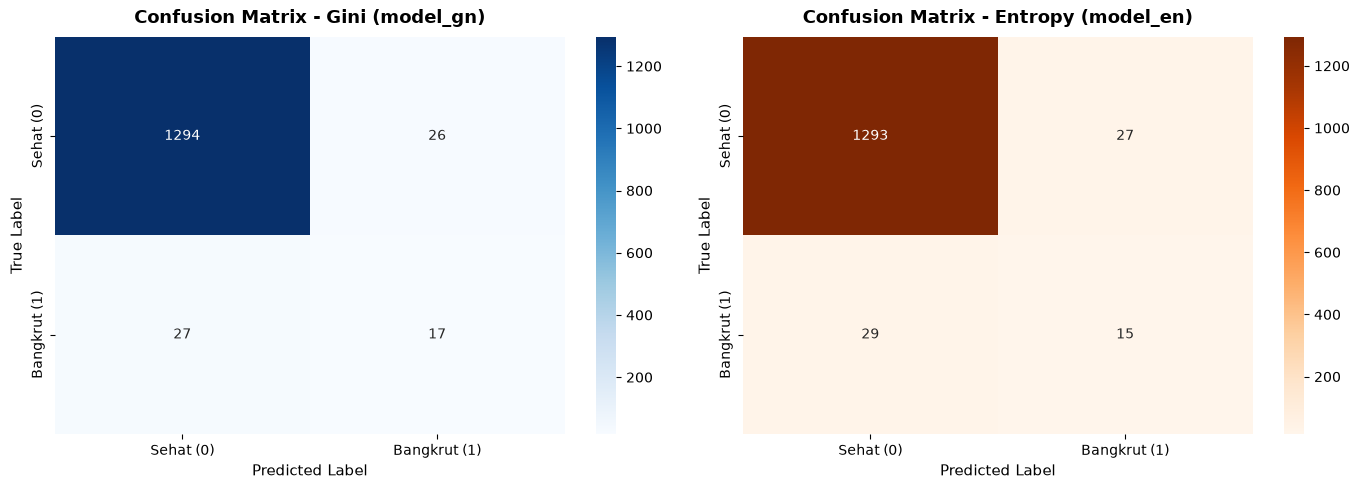

In [106]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gn = confusion_matrix(y_test, y_pred_gn)
sns.heatmap(
    cm_gn, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0],
    xticklabels=['Sehat (0)', 'Bangkrut (1)'],
    yticklabels=['Sehat (0)', 'Bangkrut (1)']
)
axes[0].set_title('Confusion Matrix - Gini (model_gn)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

cm_en = confusion_matrix(y_test, y_pred_en)
sns.heatmap(
    cm_en, 
    annot=True, 
    fmt='d', 
    cmap='Oranges', 
    ax=axes[1],
    xticklabels=['Sehat (0)', 'Bangkrut (1)'],
    yticklabels=['Sehat (0)', 'Bangkrut (1)']
)
axes[1].set_title('Confusion Matrix - Entropy (model_en)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

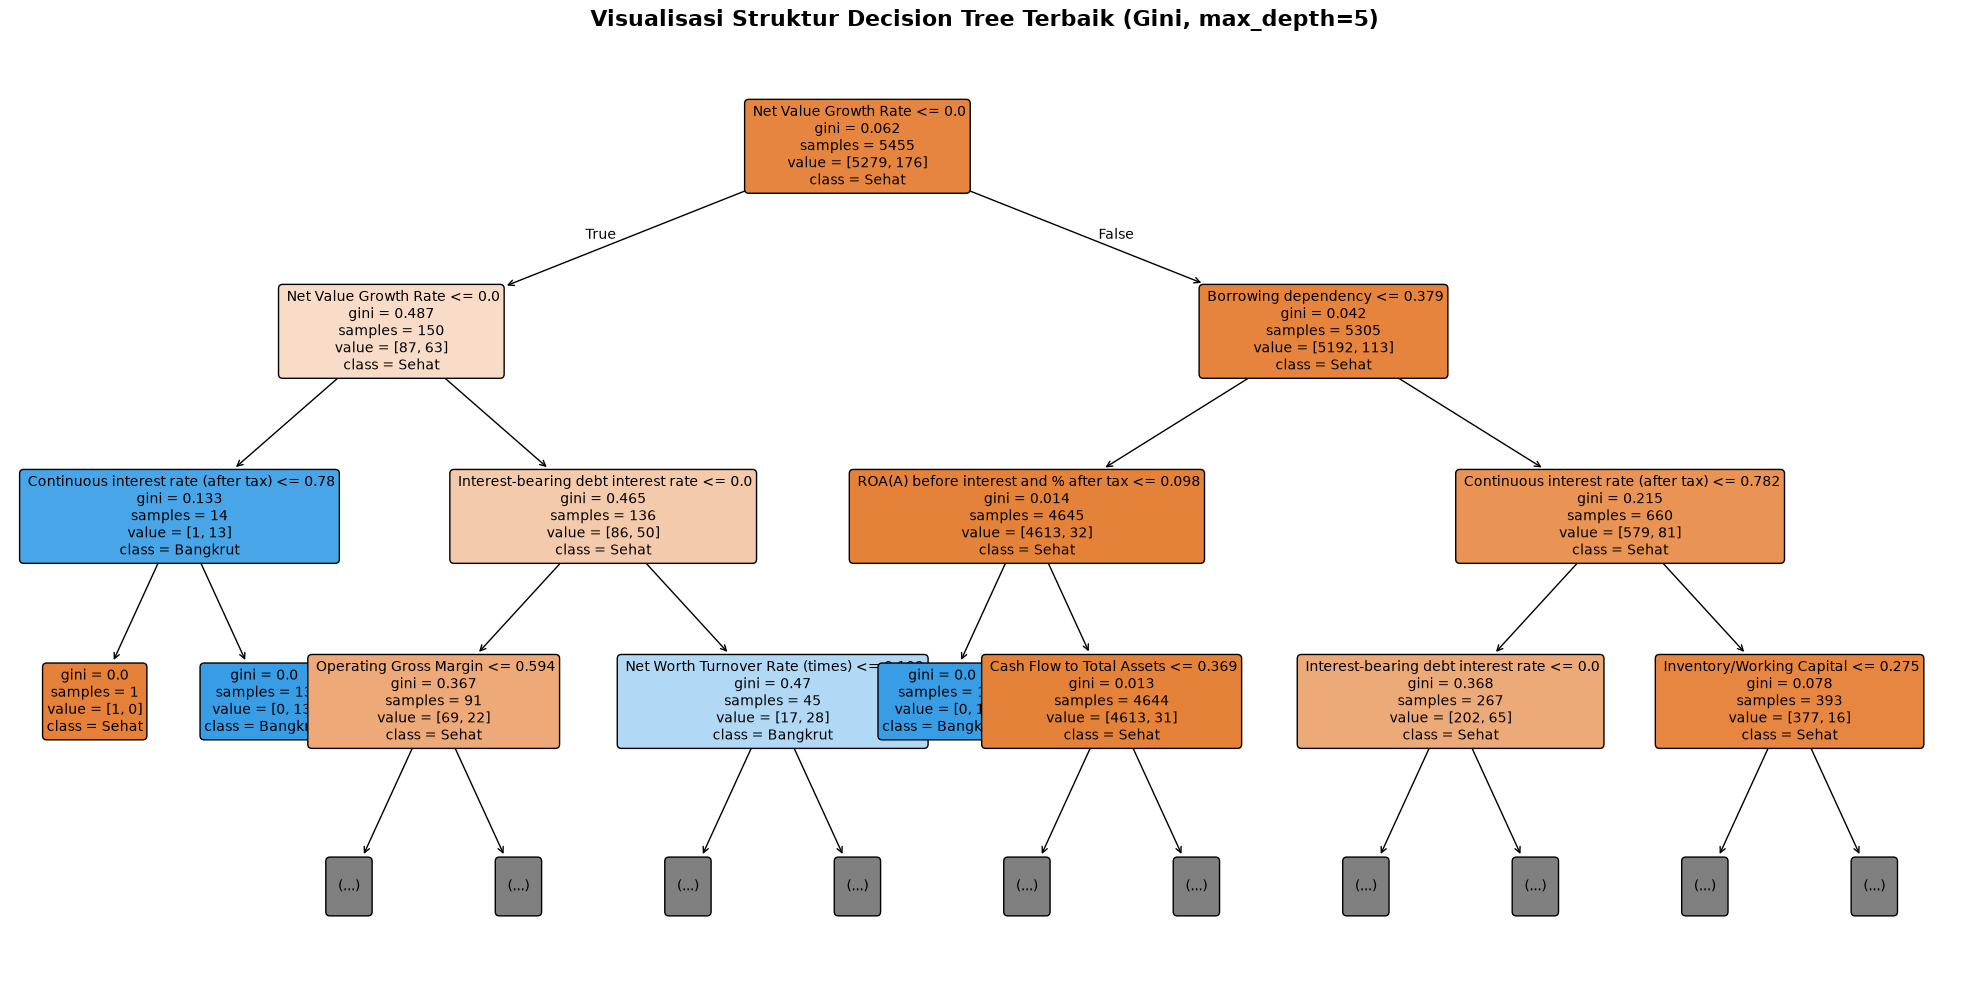

In [107]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

best_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
best_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    max_depth=3,                      
    feature_names=X_train.columns,     
    class_names=['Sehat', 'Bangkrut'], 
    filled=True,                       
    rounded=True,                      
    fontsize=10
)

plt.title('Visualisasi Struktur Decision Tree Terbaik (Gini, max_depth=5)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

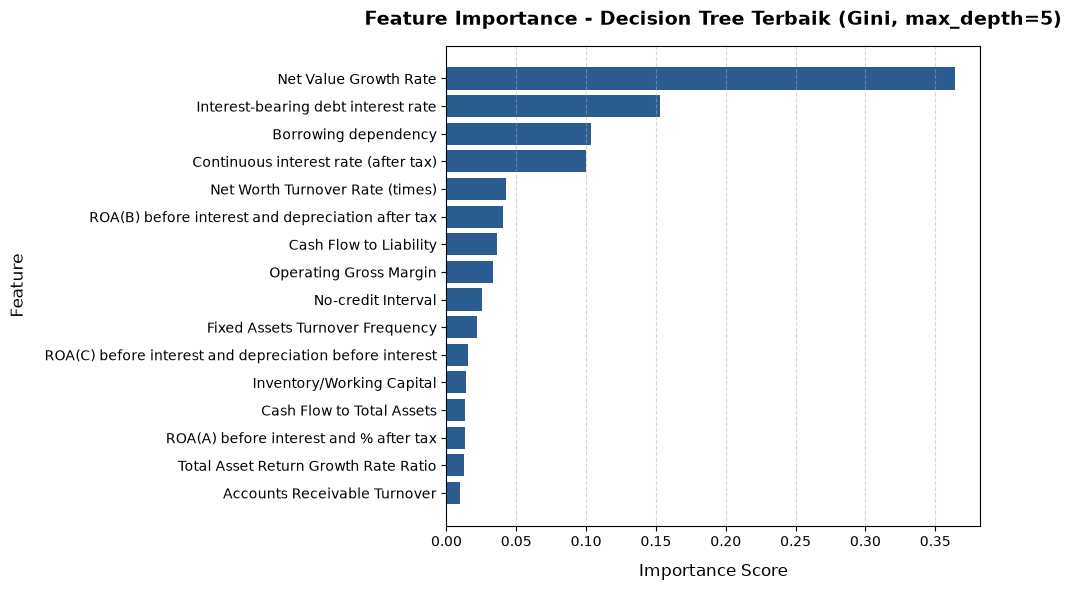

In [108]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

df_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

df_importance_active = df_importance[df_importance['Importance'] > 0].sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    df_importance_active['Feature'], 
    df_importance_active['Importance'], 
    color='#2b5c8f'
)

plt.title('Feature Importance - Decision Tree Terbaik (Gini, max_depth=5)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Feature', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Analisis Hasil Eksperimen Decision Tree

---

#### 1. Perbandingan Performa: Gini vs. Entropy

Berdasarkan hasil pengujian pada data *testing* ($X_{test}$), kriteria **Gini (`model_gn`)** menunjukkan performa yang secara konsisten lebih unggul dibandingkan **Entropy (`model_en`)** di seluruh metrik evaluasi[cite: 1]:

* **Perbandingan Metrik Utama:**
  * **Accuracy**: Gini mencapai **0,9611 (96,11%)**, sedangkan Entropy sebesar **0,9589 (95,89%)**[cite: 1].
  * **Precision (Bangkrut)**: Gini unggul di angka **0,3953 (39,53%)** dibanding Entropy di angka **0,3571 (35,71%)**[cite: 1].
  * **Recall (Bangkrut)**: Gini berhasil mengidentifikasi **0,3864 (38,64%)** perusahaan bangkrut, sedangkan Entropy hanya **0,3409 (34,09%)**[cite: 1].
  * **F1-Score (Bangkrut)**: Gini memperoleh **0,3908 (39,08%)** vs. Entropy **0,3488 (34,88%)**[cite: 1].
  * **ROC-AUC**: Gini unggul dengan **0,6833** dibanding Entropy **0,6602**[cite: 1].

* **Dampak pada Confusion Matrix:**
  * **Gini (`model_gn`)**: Memiliki nilai **True Positive (TP) = 17** dan **False Negative (FN) = 27**[cite: 4].
  * **Entropy (`model_en`)**: Memiliki nilai **True Positive (TP) = 15** dan **False Negative (FN) = 29**[cite: 4].

**Analisis Penyebab:**  
Perbedaannya tergolong cukup signifikan pada metrik kelas minoritas, dengan Recall Gini lebih tinggi sebesar 4,55% dan Precision lebih tinggi 3,82%[cite: 1].  
Secara matematis, kriteria **Gini** meminimalkan *impurity* berbasis varians probabilitas kuadrat ($1 - \sum p_i^2$). Karakteristik ini membuat pemisahan node Gini lebih responsif terhadap fitur bernilai kontinu dan mampu mengisolasi subkelompok kelas minoritas (*bangkrut*) secara lebih tegas pada dataset yang sangat *imbalanced*. Di sisi lain, **Entropy** menggunakan fungsi logaritmik ($- \sum p_i \log_2 p_i$) yang cenderung membentuk percabangan lebih seimbang secara umum, namun pada kasus kebangkrutan ini menghasilkan batas keputusan yang sedikit kurang optimal untuk menangkap kasus bangkrut[cite: 4].

---

#### 2. Temuan Eksperimen Regularisasi (`max_depth`) & Overfitting

Pengujian kedalaman pohon (`max_depth = 1, 2, 3, 5, 10, None`) menunjukkan tren performa sebagai berikut[cite: 2]:

* `max_depth = 1` $\rightarrow$ Train Acc: 0,9677 | Test Acc: 0,9677 | Test Recall: 0,0000[cite: 2]
* `max_depth = 2` $\rightarrow$ Train Acc: 0,9699 | Test Acc: 0,9699 | Test Recall: 0,0909[cite: 2]
* `max_depth = 3` $\rightarrow$ Train Acc: 0,9723 | Test Acc: 0,9714 | Test Recall: 0,2045[cite: 2]
* `max_depth = 5` $\rightarrow$ Train Acc: 0,9775 | Test Acc: 0,9692 | Test Recall: 0,4091[cite: 2]
* `max_depth = 10` $\rightarrow$ Train Acc: 0,9947 | Test Acc: 0,9611 | Test Recall: 0,3636[cite: 2]
* `max_depth = None` $\rightarrow$ Train Acc: 1,0000 | Test Acc: 0,9611 | Test Recall: 0,3864[cite: 2]

* **Titik Puncak Akurasi vs. Awal Overfitting:**
  * Murni dari grafik akurasi *training* vs *testing*, performa *testing set* mencapai titik tertinggi pada **`max_depth = 3` (0,9714)**[cite: 2, 3].
  * Gejala awal **`overfitting`** mulai terlihat saat melangkah dari **`max_depth = 3` menuju `5`**[cite: 3]. Pada rentang ini, grafik akurasi *training* terus meningkat ($0,9723 \rightarrow 0,9775$), tetapi grafik akurasi *testing* mulai menunjukkan tren penurunan ($0,9714 \rightarrow 0,9692$)[cite: 2, 3].

* **Ciri-Ciri Overfitting Ekstrem (`max_depth = 10` dan `None`):**
  * **Pelebaran Gap**: Terlihat celah yang sangat lebar antara kurva *training* dan *testing*[cite: 3].
  * **Akurasi Training Sempurna**: Pada `max_depth = None`, akurasi *training* menyentuh angka **1,0000 (100%)**[cite: 2, 3]. Model menghafal seluruh pola data latih termasuk *noise*.
  * **Akurasi Testing Stagnan/Menurun**: Di saat akurasi *train* menyentuh 100%, akurasi *testing* justru drop dan tertahan di angka **0,9611 (96,11%)**[cite: 2, 3].

**Rasionalisasi Pemilihan Model Final:**  
Meskipun `max_depth = 3` adalah puncak dari akurasi umum (97,14%)[cite: 2, 3], **`max_depth = 5`** dipilih sebagai konfigurasi paling seimbang secara praktis. Di kedalaman 5, kemampuan mendeteksi perusahaan bangkrut (*Test Recall*) melonjak dua kali lipat menjadi **40,91%** (dibanding 20,45% pada kedalaman 3)[cite: 2], dengan hanya mengorbankan 0,22% akurasi keseluruhan[cite: 2, 3].

---

#### 3. Analisis Feature Importance

Berdasarkan *bar chart* horizontal *Feature Importance* dari model terbaik (`Gini`, `max_depth=5`), terdapat beberapa indikator keuangan utama yang paling menentukan prediksi kebangkrutan[cite: 6]:

1. **`Net Value Growth Rate`**: Merupakan fitur yang paling berpengaruh secara dominan dengan *importance score* menyentuh **> 0,35 (35%)**[cite: 6]. Hal ini selaras dengan struktur grafik pohon keputusan, di mana `Net Value Growth Rate <= 0.0` dijadikan sebagai kriteria pemisahan pertama di *root node*[cite: 5]. Perusahaan yang tidak mengalami pertumbuhan nilai bersih secara langsung diarahkan ke kelompok berisiko tinggi[cite: 5].
2. **`Interest-bearing debt interest rate`**: Menduduki posisi kedua dengan kontribusi sekitar **0,15 (15%)**[cite: 6].
3. **`Borrowing dependency`**: Berada di posisi ketiga dengan kontribusi sekitar **0,10 (10%)**[cite: 6].
4. **`Continuous interest rate (after tax)`**: Berada di posisi keempat dengan kontribusi sekitar **0,10 (10%)**[cite: 6].


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan dan Saran

---

#### 1. Kesimpulan

Berdasarkan seluruh tahapan eksperimen modeling menggunakan **Decision Tree** untuk prediksi kebangkrutan perusahaan, diperoleh beberapa kesimpulan utama:

1. **Kriteria Split Terbaik**: Model dengan kriteria **Gini** unggul secara konsisten dibandingkan **Entropy** di seluruh metrik evaluasi[cite: 1]. Model Gini mampu mendeteksi lebih banyak perusahaan bangkrut secara nyata (Recall 38,6% vs 34,1% dan F1-Score 39,1% vs 34,9%)[cite: 1, 4].
2. **Kedalaman Pohon Optimal (`max_depth`)**: Pengaturan **`max_depth = 5`** merupakan titik kompromi paling optimal[cite: 2]. Meskipun `max_depth = 3` menghasilkan akurasi *testing* tertinggi (97,14%)[cite: 2, 3], kedalaman 5 berhasil melipatgandakan kemampuan deteksi kelas bangkrut (*Recall*) menjadi **40,91%**[cite: 2] tanpa mengalami *overfitting* ekstrem seperti pada `max_depth = 10` dan `None`[cite: 2, 3].
3. **Indikator Keuangan Kunci**: Berdasarkan *feature importance*, variabel **`Net Value Growth Rate`** menjadi prediktor paling dominan dengan kontribusi di atas **35%**[cite: 6]. Kinerja pertumbuhan nilai bersih serta tingginya ketergantungan pada utang berbeban bunga (`Interest-bearing debt interest rate` dan `Borrowing dependency`) merupakan faktor penentu utama kondisi kebangkrutan perusahaan[cite: 5, 6].

---

#### 2. Saran untuk Eksperimen Selanjutnya

Untuk meningkatkan performa model dan mengatasi keterbatasan yang ditemukan selama eksperimen, berikut beberapa rekomendasi langkah pengembangan selanjutnya:

1. **Penanganan Ketidakseimbangan Kelas (*Class Imbalance*)**:
   * Menggunakan teknik *resampling* seperti **SMOTE** (*Synthetic Minority Over-sampling Technique*) atau *Random UnderSampling* pada data latih.
   * Mengaktifkan parameter **`class_weight='balanced'`** pada `DecisionTreeClassifier` agar model memberikan bobot penalti yang lebih besar saat salah memprediksi kelas minoritas (*bangkrut*).
2. **Pemangkasan Pohon Tingkat Lanjut (*Pruning*)**:
   * Menerapkan *Cost Complexity Pruning* menggunakan parameter **`ccp_alpha`** untuk menemukan ukuran pohon optimal secara otomatis berbasis kriteria penalti kompleksitas, sebagai alternatif dari pembatasan kedalaman manual (`max_depth`).
3. **Eksplorasi Hyperparameter Lain**:
   * Melakukan tuning hyperparameter yang lebih rinci menggunakan `GridSearchCV` atau `RandomizedSearchCV` dengan mengombinasikan parameter lain seperti **`min_samples_leaf`**, **`min_samples_split`**, dan **`max_features`** untuk mencegah *overfitting* di tingkat daun.
4. **Uji Coba Algoritma Pembelajaran Mesin Lain**:
   * Membandingkan performa tunggal Decision Tree dengan algoritma *Ensemble Learning* berbasis pohon seperti **Random Forest**, **Gradient Boosting**, **XGBoost**, atau **LightGBM** yang umumnya lebih stabil dan memiliki daya generalisasi lebih baik pada data tabular bernilai kontinu.